In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from collections import Counter
from scipy.linalg import sqrtm
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, DensityMatrix, Statevector, partial_trace, state_fidelity
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout
from itertools import product
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler 
from qiskit_experiments.framework import ParallelExperiment
from qiskit_experiments.library import StateTomography
from scipy.optimize import brentq
from scipy.linalg import sqrtm
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import json, pickle
from collections import defaultdict

One qubit with thermal bath at temperature $T$. This is the Lindblad master equation:
$$ \dot{\rho} = \frac{-i}{\hbar}[H, \rho] + \mathcal{L}$$
where:
$$ H = \frac{\hbar \omega}{2} \sigma_z$$
$$ \mathcal{L(\rho)} = \Gamma (n+1) \left( \sigma_- \rho \sigma_+ - \frac{1}{2} \{ \sigma_+ \sigma_-, \rho \}  \right) + 
\Gamma n \left( \sigma_+ \rho \sigma_- - \frac{1}{2} \{ \sigma_- \sigma_+, \rho \}  \right) $$

We will choose as the operator basis $\{ G_l \}$:  
$G_0 = \mathbb{I}/2$, $G_1 = \sigma_x/2$, $G_2 = \sigma_y/2$, $G_3 = \sigma_z/2$

$$ \Lambda_t (G_l) = \frac{-i}{\hbar}[H, G_l] + \mathcal{L}(G_l) $$

$$L_{ki} = Tr[G_k \Lambda(G_i)]$$

$$ F(t) = e^{Lt} $$

$$ S_{ab} = \sum_{rs} F_{sr} Tr[G_r H_a^\dagger G_s H_b] $$

Diagonalising $S$ we obtain $X_j$ and the Kraus operators satisfy $A_j = \sqrt{\lambda_j} X_j$

The steady state is:
$$ \rho_{ss} = \frac{1}{2n+1} \begin{pmatrix}
n+1 & 0 \\
0 & n
\end{pmatrix}
$$

We want to convert the Kraus operators into unitary gates:
$$ U_A = \begin{pmatrix}
A & D_{A^\dagger} \\
D_A & -A^\dagger
\end{pmatrix}
$$

where:
$ D_A = \sqrt{\mathbb{I} - A^\dagger A} $ and $A$ is one of our Kraus operators

These matrices are not exactly unitary, so we use the SVD ($U_A^{before} = V\Sigma W^\dagger$) to make them exactly unitary ($U_A^{exact} = V\mathbb{I} W^\dagger$)

CODE TO OBTAIN U_A_i:

In [2]:
identity = np.array([[1.0, 0.0],
                        [0.0, 1.0]], dtype=complex)

sigma_z = np.array([[1.0, 0.0],
                        [0.0, -1.0]], dtype=complex)

sigma_plus = np.array([[0.0, 1.0],
                        [0.0, 0.0]], dtype=complex)

sigma_minus = np.array([[0.0, 0.0],
                        [1.0, 0.0]], dtype=complex)

In [3]:
# G_l operators
G_0 = np.array([[1.0, 0.0],
                [0.0, 1.0]], dtype=complex) / np.sqrt(2)
G_1 = np.array([[0.0, 1.0],
                [1.0, 0.0]], dtype=complex) / np.sqrt(2)
G_2 = np.array([[0.0, -1j],
                [+1j, 0.0]], dtype=complex) / np.sqrt(2)
G_3 = np.array([[1.0, 0.0],
                [0.0, -1.0]], dtype=complex) / np.sqrt(2)

Gs = [G_0, G_1, G_2, G_3]

In [4]:
def get_U_Ai_matrices(w, Gamma, T, dt, h_bar=1, k_b=1):
    
    # n (thermal occupancy)
    if T == 0:
        n_thermal = 0
    else:
        n_thermal = 1 / (np.exp((h_bar * w) / (k_b * T)) - 1)
        
    H = h_bar * w / 2 * sigma_z
    dim = 2

    # map Lambda(G_l) = -i/h_bar [H,G_l] + L(G_l)
    def L(rho):
        pm = np.dot(sigma_plus, sigma_minus)
        mp = np.dot(sigma_minus, sigma_plus)
        anti_pm = np.dot(pm, rho) + np.dot(rho, pm)
        anti_mp = np.dot(mp, rho) + np.dot(rho, mp)
        emm = Gamma * (n_thermal + 1) * (np.dot(sigma_minus, np.dot(rho, sigma_plus)) - 0.5 * anti_pm)
        abso = Gamma * n_thermal * (np.dot(sigma_plus, np.dot(rho, sigma_minus)) - 0.5 * anti_mp)
        return emm + abso

    def lambdaa(op):
        comm = np.dot(H, op) - np.dot(op, H)
        return (-1j/h_bar) * comm + L(op)

    # We compute Lambda(G_l) for each of our G_l
    lambda_G = [lambdaa(G) for G in Gs]

    # L_ki = Tr(G_k Lambda(G_i))
    L_matrix = np.zeros((dim**2, dim**2), dtype=complex)
    for k in range(dim**2):
        for i in range(dim**2):
            L_matrix[k,i] = np.trace(np.dot(Gs[k], lambda_G[i]))

    # We diagonalize L to compute F = exp(Lt)
    eigenval, eigenvect = np.linalg.eig(L_matrix)
    P = eigenvect
    P_inv = np.linalg.inv(P)
    exp_Lt = np.diag(np.exp(eigenval * dt))
    F_t = np.dot(np.dot(P, exp_Lt), P_inv)

    # We calculate S_matrix
    S_matrix = np.zeros((dim**2, dim**2), dtype=complex)
    for a in range(dim**2):
        H_a_dag = np.conjugate(Gs[a]).T
        for b in range(dim**2):
            S_ab_sum = 0.0 + 0.0j
            for s in range(dim**2):
                for r in range(dim**2):
                    F_sr = F_t[s,r]
                    S_ab_sum += F_sr * np.trace(np.dot(np.dot(np.dot(Gs[r], H_a_dag), Gs[s]), Gs[b]))
            S_matrix[a, b] = S_ab_sum

    def kraus(S_matrix, Gs):
        # We diagonalise S
        lambda_k, X_k_eigenvectors = np.linalg.eig(S_matrix)
        kraus_op_list = []

        for k in range(dim**2):
            if np.real(lambda_k[k]) > 1e-10:
                lambda_k_val = lambda_k[k]
                X_k = X_k_eigenvectors[:, k] #column
        
                A_k_matrix = np.zeros((dim, dim), dtype=complex)
                for j in range(len(Gs)):
                    A_k_matrix += X_k[j] * Gs[j]
        
                kraus_op = np.sqrt(lambda_k_val) * A_k_matrix
                kraus_op_list.append(kraus_op)

        return lambda_k, X_k_eigenvectors, kraus_op_list

    # Function to convert them into exactly unitary matrices
    def exact_unitary(matrix):
        V, s, Wh = np.linalg.svd(matrix)
        return V @ Wh

    # We obtain Kraus operators
    lambda_k, X_k_eigenvectors, A_k = kraus(S_matrix, Gs)

    # Build Unitaries
    U_Ai_matrices = []
    for i, A_i in enumerate(A_k):
        A_dagger_i = A_i.conj().T
        diff = identity - (A_dagger_i @ A_i)
        diff = (diff + diff.conj().T) / 2 + np.eye(2) * 1e-12
        D_Ai = sqrtm(diff)
        D_Ai_dagger = D_Ai.conj().T
        U_Ai = np.block([
            [A_i,           D_Ai_dagger],
            [D_Ai,          -A_dagger_i]
        ])
        U_Ai_matrices.append(exact_unitary(U_Ai))
        
    return U_Ai_matrices, A_k

OTHER GENERAL FUNCTIONS:

In [5]:
def add_basis_rotation(qc, qubit, basis):
    if basis == 'X':
        qc.h(qubit)
    elif basis == 'Y':
        qc.sdg(qubit)
        qc.h(qubit)
    # basis == 'Z' -> no rotation

In [6]:
def fidelity(rho1, rho2):
    # F(rho1, rho2) = Tr[sqrt( sqrt(rho1) * rho2 * sqrt(rho1) )]
    rho1 = np.asarray(rho1, dtype=complex)
    rho2 = np.asarray(rho2, dtype=complex)

    sqrt_rho1 = sqrtm(rho1)
    M = sqrt_rho1 @ rho2 @ sqrt_rho1
    sqrt_M = sqrtm(M)
    tr_sqrt_M = np.real(np.trace(sqrt_M))

    return np.clip(tr_sqrt_M, 0.0, 1.0)

In [7]:
def build_circuit(U_i, basis, purified_state):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "meas")
    qc = QuantumCircuit(qr, cr)
    # q0 = ancilla Sz-Nagy, q1 = system, q2 = purification
    qc.initialize(purified_state, [1, 2])
    qc.unitary(Operator(U_i), [1, 0])
    add_basis_rotation(qc, 1, basis)
    qc.measure(0, 0)  # ancilla
    qc.measure(1, 1)  # system
    return qc

In [8]:
# calculate the diagonal matrix projected normalizing counts by shots
def basis_expectation_from_counts(branch_counts, shots):
    acc = np.zeros((2, 2), dtype=float)
    for N00, N10 in branch_counts:
        N = N00 + N10
        if N == 0:
            continue
        acc += np.array([[N00 / shots, 0.0], [0.0, N10 / shots]])
    tr = np.trace(acc)
    return acc / tr if tr != 0 else acc

----

## FIXED TEMPERATURE (populations & coherences)

In [9]:
# Parameters 
w_ind = 1.0 
#w_ind = 1.0
Gamma_ind = 0.1
#Gamma_ind = 0.00152 
T_ind = 6.0 #K
desired_time_ind = 10
N_steps_ind = 20
dt_ind = desired_time_ind/ (N_steps_ind - 1)

In [10]:
# Initial state
current_rho_ind = np.array([[0.75, 0.25], 
                        [0.25, 0.25]], dtype=complex)

# PURIFICATION (for real hardware)
# We calculate the eignevalues and eigenvectors to build the equivalent pure state in 2 qubits
eigenvalues_ind, eigenvectors_ind = np.linalg.eigh(current_rho_ind)

# |Psi> = sqrt(p0)|v0>|0> + sqrt(p1)|v1>|1>
purified_state_ind = np.zeros(4, dtype=complex)
purified_state_ind[0:2] = np.sqrt(eigenvalues_ind[0]) * eigenvectors_ind[:, 0] # aux |0>
purified_state_ind[2:4] = np.sqrt(eigenvalues_ind[1]) * eigenvectors_ind[:, 1] # aux |1>

In [11]:
# theory
times_ind = np.arange(0, N_steps_ind * dt_ind, dt_ind) * Gamma_ind
rho00_theo_ind, rho11_theo_ind = [], []
rho01_re_ind, rho01_im_ind = [], []
rho10_re_ind, rho10_im_ind = [], []
rho_theo_list_ind = []
rho_initial_ind = current_rho_ind.copy()

for n_idx in range(N_steps_ind):

    t_n = n_idx * dt_ind

    if n_idx == 0:
        rho_res_ind = rho_initial_ind.copy()

    else:

        U_n_ind, _ = get_U_Ai_matrices(w_ind, Gamma_ind, T_ind, t_n)

        rho_total_ind = np.zeros((2,2), dtype=complex)

        for i in range(len(U_n_ind)):

            rho_ancilla_ind = np.array([[1,0],[0,0]], dtype=complex)

            rho_in_ind = DensityMatrix(np.kron(rho_ancilla_ind, rho_initial_ind))

            c_ind = QuantumCircuit(2)
            c_ind.unitary(Operator(U_n_ind[i]), [0,1])

            rho_final_ind = rho_in_ind.evolve(c_ind).data
            rho_i_ind = rho_final_ind[:2,:2] 

            rho_total_ind += rho_i_ind

        rho_res_ind = rho_total_ind / np.trace(rho_total_ind)

    rho00_theo_ind.append(np.real(rho_res_ind[0,0]))
    rho11_theo_ind.append(np.real(rho_res_ind[1,1]))
    
    rho01_re_ind.append(np.real(rho_res_ind[0,1]))
    rho01_im_ind.append(np.imag(rho_res_ind[0,1]))

    rho10_re_ind.append(np.real(rho_res_ind[1,0]))  
    rho10_im_ind.append(np.imag(rho_res_ind[1,0]))  

    rho_theo_list_ind.append(DensityMatrix(rho_res_ind))

In [12]:
# RECONSTRUCTING WHOLE DENSITY MATRIX
USE_IBM_HARDWARE = False   # set to True to send this to a real IBM backend
shots = 20000
all_circuits_ind = []
circuit_meta_ind = []

for n in range(N_steps_ind):
    t_n = n * dt_ind
    if n == 0:
        continue

    U_n_ind, _ = get_U_Ai_matrices(w_ind, Gamma_ind, T_ind, t_n)

    for basis in ["Z", "X", "Y"]:
        for branch_idx, U_i_ind in enumerate(U_n_ind):
            qc_ind = build_circuit(U_i_ind, basis, purified_state_ind)
            all_circuits_ind.append(qc_ind)
            circuit_meta_ind.append(
                {"step": n, "basis": basis, "branch": branch_idx}
            )

print(f"Total circuits to send: {len(all_circuits_ind)}")

# CONFIGURE BACKEND AND SEND JOBS
if USE_IBM_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    service_ind = QiskitRuntimeService(channel="ibm_quantum_platform")
    backend_ind = service_ind.least_busy(operational=True, min_num_qubits=3)
    sampler_ind = Sampler(mode=backend_ind)
else:
    from qiskit_aer import AerSimulator
    from qiskit_aer.primitives import SamplerV2 as Sampler

    backend_ind = AerSimulator()
    sampler_ind = Sampler()

print("Backend:", getattr(backend_ind, "name", backend_ind))

pm_ind = generate_preset_pass_manager(backend=backend_ind, optimization_level=1)
isa_circuits_ind = [pm_ind.run(qc_ind) for qc_ind in all_circuits_ind]

MAX_CIRCUITS_PER_JOB = 300 if USE_IBM_HARDWARE else len(isa_circuits_ind)
job_records_ind = []

for start in range(0, len(isa_circuits_ind), MAX_CIRCUITS_PER_JOB):
    chunk_ind = isa_circuits_ind[start : start + MAX_CIRCUITS_PER_JOB]
    job_ind = sampler_ind.run(chunk_ind, shots=shots)

    record_ind = {
        "mode": "ibm" if USE_IBM_HARDWARE else "local",
        "start": start,
        "end": start + len(chunk_ind),
    }

    if USE_IBM_HARDWARE:
        record_ind["job_id"] = job_ind.job_id()
        record_ind["backend"] = backend_ind.name
        print(f"Submitted job: {job_ind.job_id()}")
    else:
        result_ind = job_ind.result()
        counts_chunk_ind = [pub_result_ind.data.meas.get_counts() for pub_result_ind in result_ind]
        chunk_file_ind = f"local_counts_scirep_ind_{start}.pkl"
        with open(chunk_file_ind, "wb") as f:
            pickle.dump(counts_chunk_ind, f)
        record_ind["counts_file"] = chunk_file_ind

    job_records_ind.append(record_ind)

# RETRIEVE RESULTS
all_counts_ind = [None] * len(circuit_meta_ind)

for rec in job_records_ind:
    if rec["mode"] == "ibm":
        job_ind = service_ind.job(rec["job_id"])
        result_ind = job_ind.result()
        counts_chunk_ind = [
            pub_result_ind.data.meas.get_counts() for pub_result_ind in result_ind
        ]
    else:
        with open(rec["counts_file"], "rb") as f:
            counts_chunk_ind = pickle.load(f)

    for local_idx, counts in enumerate(counts_chunk_ind):
        all_counts_ind[rec["start"] + local_idx] = counts

grouped_ind = defaultdict(list)
for meta, counts in zip(circuit_meta_ind, all_counts_ind):
    key_ind = (meta["step"], meta["basis"])
    N00_ind = counts.get("00", 0)
    N10_ind = counts.get("10", 0)
    grouped_ind[key_ind].append((N00_ind, N10_ind))


# Save experimental data
rho00_exp_ind = [rho00_theo_ind[0]]
rho11_exp_ind = [rho11_theo_ind[0]]
rho01_re_exp_ind = [np.real(current_rho_ind[0, 1])]
rho01_im_exp_ind = [np.imag(current_rho_ind[0, 1])]
rho10_re_exp_ind = [np.real(current_rho_ind[1, 0])]
rho10_im_exp_ind = [np.imag(current_rho_ind[1, 0])]

# Lists of uncertianties
err_rho00_ind, err_rho11_ind = [0.0], [0.0]
err_rho01_re_ind, err_rho01_im_ind = [0.0], [0.0]
err_rho10_re_ind, err_rho10_im_ind = [0.0], [0.0]

rho_exp_matrices_ind = [current_rho_ind.copy()]
fidelities_ind = [fidelity(rho_theo_list_ind[0], current_rho_ind)]

for n in range(1, N_steps_ind):
    diag_Z_ind = basis_expectation_from_counts(grouped_ind[(n, "Z")], shots)
    diag_X_ind = basis_expectation_from_counts(grouped_ind[(n, "X")], shots)
    diag_Y_ind = basis_expectation_from_counts(grouped_ind[(n, "Y")], shots)

    z_exp_ind = diag_Z_ind[0, 0] - diag_Z_ind[1, 1]
    x_exp_ind = diag_X_ind[0, 0] - diag_X_ind[1, 1]
    y_exp_ind = diag_Y_ind[0, 0] - diag_Y_ind[1, 1]

    rho_n_ind = np.array(
        [
            [0.5 * (1 + z_exp_ind), 0.5 * (x_exp_ind - 1j * y_exp_ind)],
            [0.5 * (x_exp_ind + 1j * y_exp_ind), 0.5 * (1 - z_exp_ind)],
        ],
        dtype=complex,
    )

    r00_ind = np.real(rho_n_ind[0, 0])
    r11_ind = np.real(rho_n_ind[1, 1])
    r01_re_ind = np.real(rho_n_ind[0, 1])
    r01_im_ind = np.imag(rho_n_ind[0, 1])

    rho00_exp_ind.append(r00_ind)
    rho11_exp_ind.append(r11_ind)
    rho01_re_exp_ind.append(r01_re_ind)
    rho01_im_exp_ind.append(r01_im_ind)
    rho10_re_exp_ind.append(r01_re_ind)
    rho10_im_exp_ind.append(-r01_im_ind)

    # Uncertainties of matrix elements
    u_r00_ind = 0.5 * np.sqrt(max(0.0, 1.0 - z_exp_ind**2) / shots)
    u_r01_re_ind = 0.5 * np.sqrt(max(0.0, 1.0 - x_exp_ind**2) / shots)
    u_r01_im_ind = 0.5 * np.sqrt(max(0.0, 1.0 - y_exp_ind**2) / shots)

    err_rho00_ind.append(u_r00_ind)
    err_rho11_ind.append(u_r00_ind)
    err_rho01_re_ind.append(u_r01_re_ind)
    err_rho01_im_ind.append(u_r01_im_ind)
    err_rho10_re_ind.append(u_r01_re_ind)
    err_rho10_im_ind.append(u_r01_im_ind)

    rho_exp_matrices_ind.append(rho_n_ind)
    fidelities_ind.append(fidelity(rho_theo_list_ind[n], rho_n_ind))

print("All the data are saved")

Total circuits to send: 228
Backend: aer_simulator
All the data are saved


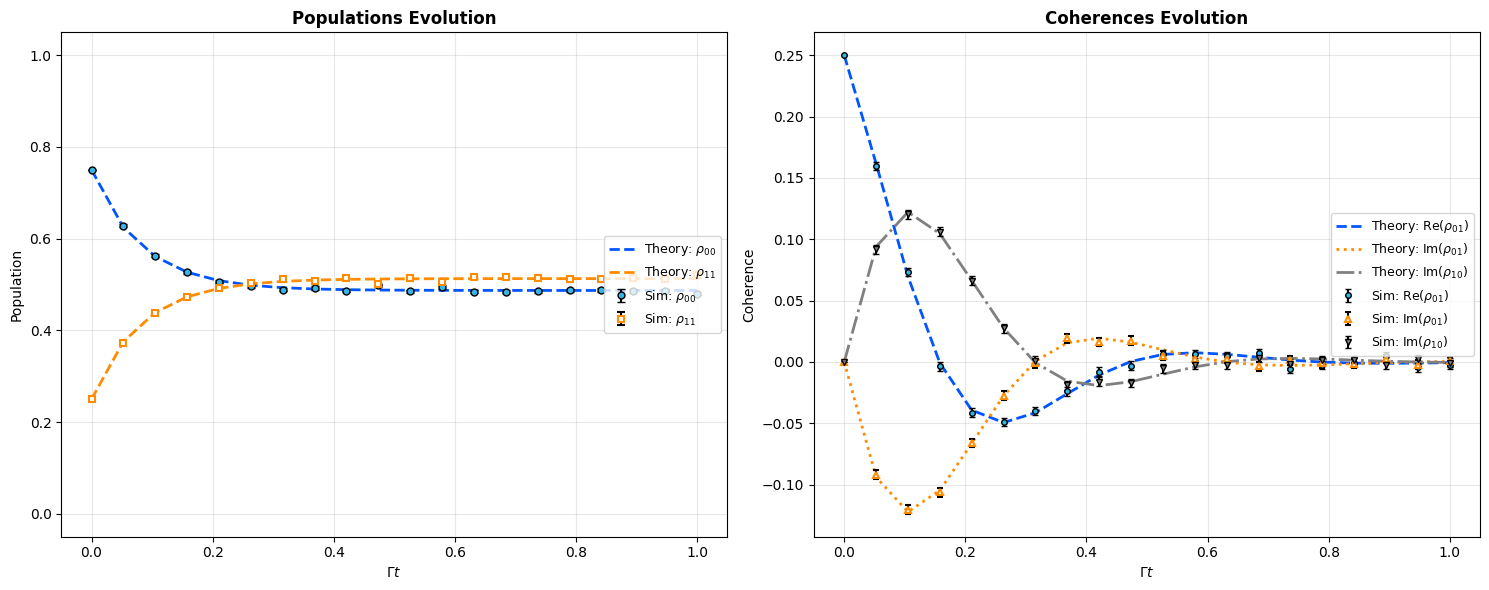

In [13]:
# PLOT: POPULATIONS AND COHERENCES 

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

# POPULATIONS
axes[0].plot(
    times_ind, rho00_theo_ind, label=r"Theory: $\rho_{00}$", color="#0055FF", lw=2, ls="--"
)
axes[0].plot(
    times_ind, rho11_theo_ind, label=r"Theory: $\rho_{11}$", color="#FF8C00", lw=2, ls="--"
)

axes[0].errorbar(
    times_ind,
    rho00_exp_ind,
    yerr=err_rho00_ind,
    fmt="o",
    color="#33B5E5",
    ecolor="black",
    markeredgecolor="black",
    capsize=3,
    markersize=5,
    label=r"Sim: $\rho_{00}$",
)
axes[0].errorbar(
    times_ind,
    rho11_exp_ind,
    yerr=err_rho11_ind,
    fmt="s",
    color="white",
    ecolor="black",
    markeredgecolor="#FF8C00",
    markeredgewidth=1.5,
    capsize=3,
    markersize=5,
    label=r"Sim: $\rho_{11}$",
)

axes[0].set_title("Populations Evolution", fontsize=12, fontweight="bold")
axes[0].set_xlabel(r"$\Gamma t$", fontsize=10)
axes[0].set_ylabel("Population", fontsize=10)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc="center right")

# COHERENCES
axes[1].plot(
    times_ind, rho01_re_ind, label=r"Theory: Re($\rho_{01}$)", color="#0055FF", lw=2, ls="--"
)
axes[1].plot(
    times_ind, rho01_im_ind, label=r"Theory: Im($\rho_{01}$)", color="#FF8C00", lw=2, ls=":"
)

axes[1].plot(
    times_ind, rho10_im_ind, label=r"Theory: Im($\rho_{10}$)", color="gray", lw=2, ls="-."
) 


axes[1].errorbar(
    times_ind,
    rho01_re_exp_ind,
    yerr=err_rho01_re_ind,
    fmt="o",
    color="#33B5E5",
    ecolor="black",
    markeredgecolor="black",
    capsize=2,
    markersize=4,
    label=r"Sim: Re($\rho_{01}$)",
)
axes[1].errorbar(
    times_ind,
    rho01_im_exp_ind,
    yerr=err_rho01_im_ind,
    fmt="^",
    color="white",
    ecolor="black",
    markeredgecolor="#FF8C00",
    markeredgewidth=1.5,
    capsize=2,
    markersize=4,
    label=r"Sim: Im($\rho_{01}$)",
)
axes[1].errorbar(
    times_ind,
    rho10_im_exp_ind,
    yerr=err_rho10_im_ind,
    fmt="v",
    color="gray",
    ecolor="black",
    markeredgecolor="black",
    capsize=2,
    markersize=4,
    label=r"Sim: Im($\rho_{10}$)",
)

axes[1].set_title("Coherences Evolution", fontsize=12, fontweight="bold")
axes[1].set_xlabel(r"$\Gamma t$", fontsize=10)
axes[1].set_ylabel("Coherence", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc="center right")

plt.tight_layout()
plt.savefig("pop_coh_ind_T6.png", dpi=300, bbox_inches="tight")
plt.show()


---------------------------------

## ASIMETRIES (fidelity & populations & coherences)

GENERAL FUNCTION FOR THIS SECTION:

In [14]:
def get_thermal_state(T_sys):
    if T_sys == 0:
        return np.array([[0.0, 0.0], [0.0, 1.0]], dtype=complex)

    E_e = +0.5 * h_bar * w  # |0>
    E_g = -0.5 * h_bar * w  # |1>

    w0 = np.exp(-E_e / (k_b * T_sys))
    w1 = np.exp(-E_g / (k_b * T_sys))

    Z = w0 + w1
    p0 = w0 / Z
    p1 = w1 / Z

    return np.array([[p0, 0.0], [0.0, p1]], dtype=complex)

In [15]:
h_bar = 1.0
k_b = 1.0
w = 1.0
Gamma = 0.1

gamma_t_max = 3.0
N_steps = 30
dt = gamma_t_max / (Gamma * (N_steps - 1))
times = np.arange(0, N_steps * dt, dt)
gamma_t_axis = Gamma * times

backend = AerSimulator()
shots = 8192

In [16]:
T_W = (h_bar * w) / (2 * k_b)
T_H = (h_bar * w) / k_b + T_W

rho_W, rho_H = get_thermal_state(T_W), get_thermal_state(T_H)
F_target = fidelity(rho_H, rho_W)

# We look for T_C such that F(T_C, T_W) == F(T_H, T_W)
T_C = brentq(lambda Tc: fidelity(get_thermal_state(Tc), rho_W) - F_target,
             0.05, T_W - 1e-6)

print(T_W, T_C, T_H)  

experiments_config = [
    (T_W, T_H, r"$T_W \rightarrow T_H$"),
    (T_C, T_W, r"$T_C \rightarrow T_W$"),
    (T_H, T_W, r"$T_H \rightarrow T_W$"),
    (T_W, T_C, r"$T_W \rightarrow T_C$"),
]

0.5 0.20136228390596508 1.5


### 3 TEMPERATURES PROTOCOL

In [17]:
# THEORETICAL EVOLUTION
theo_results = []

for T_system, T_bath, label in experiments_config:
    rho_initial = get_thermal_state(T_system)
    rho_theo_list = []

    for n_idx in range(N_steps):
        t_n = n_idx * dt
        if n_idx == 0:
            rho_res = rho_initial.copy()
        else:
            U_n, _ = get_U_Ai_matrices(w, Gamma, T_bath, t_n)
            rho_total = np.zeros((2, 2), dtype=complex)

            for U_i in U_n:
                rho_ancilla = np.array([[1, 0], [0, 0]], dtype=complex)
                rho_in = DensityMatrix(np.kron(rho_ancilla, rho_initial))

                qc = QuantumCircuit(2)
                qc.unitary(Operator(U_i), [0, 1])

                rho_final = rho_in.evolve(qc).data
                rho_total += rho_final[:2, :2]

            rho_res = rho_total / np.trace(rho_total)

        rho_theo_list.append(rho_res)

    theo_results.append(
        {
            "T_system": T_system,
            "T_bath": T_bath,
            "gamma_t_axis": gamma_t_axis,
            "label": label,
            "rho_initial": rho_initial,
            "rho_theo_list": rho_theo_list,
        }
    )

print("Completed")

Completed


In [18]:
# BUILD ALL CIRCUITS FOR THE 4 EXPERIMENTS
all_circuits = []
circuit_meta = []
U_n_cache = {}

for exp_idx, exp in enumerate(theo_results):
    rho_initial = exp["rho_initial"]
    T_bath = exp["T_bath"]

    eigenvalues, eigenvectors = np.linalg.eigh(rho_initial)
    purified_state = np.zeros(4, dtype=complex)
    purified_state[0:2] = np.sqrt(eigenvalues[0]) * eigenvectors[:, 0]
    purified_state[2:4] = np.sqrt(eigenvalues[1]) * eigenvectors[:, 1]

    for n in range(N_steps):
        t_n = n * dt
        U_n, _ = get_U_Ai_matrices(w, Gamma, T_bath, t_n)
        U_n_cache[(exp_idx, n)] = U_n

        for basis in ["Z", "X", "Y"]:
            for branch_idx, U_i in enumerate(U_n):
                qc = build_circuit(U_i, basis, purified_state)
                all_circuits.append(qc)
                circuit_meta.append(
                    {"exp_idx": exp_idx, "step": n, "basis": basis, "branch": branch_idx}
                )

print(f"Total circuits to send: {len(all_circuits)}")

Total circuits to send: 1404


In [19]:
# CONFIGURE BACKEND AND SEND THE JOB.
USE_IBM_HARDWARE = False   # set to True to send this to a real IBM backend

if USE_IBM_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    service = QiskitRuntimeService(channel="ibm_quantum_platform")
    backend = service.least_busy(operational=True, min_num_qubits=3)
    sampler = Sampler(mode=backend)
else:
    from qiskit_aer import AerSimulator
    from qiskit_aer.primitives import SamplerV2 as Sampler

    backend = AerSimulator()
    sampler = Sampler()  

print("Backend:", backend.name if hasattr(backend, "name") else backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuits = [pm.run(qc) for qc in all_circuits] # transpile

# we define a limit of circuits per job
MAX_CIRCUITS_PER_JOB = 300 if USE_IBM_HARDWARE else len(isa_circuits)

job_records = []
# loop with steps of size MAX_CIRCUITS_PER_JOB
for start in range(0, len(isa_circuits), MAX_CIRCUITS_PER_JOB):
    # extract the subset of circuits corresponding to the current block
    chunk = isa_circuits[start : start + MAX_CIRCUITS_PER_JOB]
    # send the block of circuits
    job = sampler.run(chunk, shots=shots)

    # dictionary to save trazability data of the block
    record = {
        "mode": "ibm" if USE_IBM_HARDWARE else "local",
        "start": start,
        "end": start + len(chunk),
    }

    if USE_IBM_HARDWARE:
        record["job_id"] = job.job_id()
        record["backend"] = backend.name
        print(f"Submitted job {job.job_id()} for circuits [{start}:{start + len(chunk)})")
    else:
        result = job.result()
        # extract the counts dictionaries
        counts_chunk = [pub_result.data.meas.get_counts() for pub_result in result]
        # name of the file to save results
        chunk_file = f"local_counts_{start}.pkl"
        with open(chunk_file, "wb") as f:
            pickle.dump(counts_chunk, f)
        record["counts_file"] = chunk_file
        print(f"Ran locally: circuits [{start}:{start + len(chunk)}) -> {chunk_file}")

    job_records.append(record)

# save mode and indexes and counts
with open("ibm_jobs.json", "w") as f:
    json.dump(job_records, f, indent=2)

# save list of dictionaries to know what does position k represent, which of the 4 experiments is,
# the time step, the tomography basis, and the (branch) index of U_i,
# and a dictionary of the theoretical U_i calculated
with open("circuit_meta.pkl", "wb") as f:
    pickle.dump({"circuit_meta": circuit_meta, "U_n_cache": U_n_cache}, f)

print("Everything is saved")

Backend: aer_simulator
Ran locally: circuits [0:1404) -> local_counts_0.pkl
Everything is saved


In [20]:
# RETRIEVE RESULTS AND BUILD exp_data_saved
# open and read json to recover jobs
with open("ibm_jobs.json") as f:
    job_records = json.load(f)

# open and read pkl to reocver data
with open("circuit_meta.pkl", "rb") as f:
    cache = pickle.load(f)
circuit_meta = cache["circuit_meta"]

# create an empty list with the size of the total number of circuits
all_counts = [None] * len(circuit_meta)

if any(rec["mode"] == "ibm" for rec in job_records): # if sent to IBM
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(channel="ibm_quantum_platform")

# iterate over the jobs already runned
for rec in job_records:
    if rec["mode"] == "ibm":
        # if it comes from IBM download the results
        job = service.job(rec["job_id"])
        result = job.result()
        counts_chunk = [pub_result.data.meas.get_counts() for pub_result in result]
    else:
        with open(rec["counts_file"], "rb") as f:
            counts_chunk = pickle.load(f)
    for local_idx, counts in enumerate(counts_chunk):
        all_counts[rec["start"] + local_idx] = counts

print("Retrieved results for", len(all_counts), "circuits")

# save the tuple of counts (N00, N10) into the list grouped
grouped = defaultdict(list)
for meta, counts in zip(circuit_meta, all_counts):
    key = (meta["exp_idx"], meta["step"], meta["basis"])
    N00 = counts.get("00", 0)
    N10 = counts.get("10", 0)
    grouped[key].append((N00, N10))

exp_data_saved = []
for exp_idx, exp in enumerate(theo_results):
    label = exp["label"]
    T_bath = exp["T_bath"]

    # THEORETICAL
    rho_theo_list = exp["rho_theo_list"]

    rho00_theo = [np.real(r[0, 0]) for r in rho_theo_list]
    rho11_theo = [np.real(r[1, 1]) for r in rho_theo_list]
    rho01_re_theo = [np.real(r[0, 1]) for r in rho_theo_list]
    rho01_im_theo = [np.imag(r[0, 1]) for r in rho_theo_list]
    rho10_re_theo = [np.real(r[1, 0]) for r in rho_theo_list]
    rho10_im_theo = [np.imag(r[1, 0]) for r in rho_theo_list]

    # target thermal state and populations
    rho_target = get_thermal_state(T_bath)
    p0_tgt = np.real(rho_target[0, 0])
    p1_tgt = np.real(rho_target[1, 1])

    # THEORETICAL FIDELITY: exact Lindblad evolution vs target thermal state
    fidelities_theo = [fidelity(r, rho_target) for r in rho_theo_list]

    # Save experimental data
    rho00_exp, rho11_exp = [], []
    rho01_re_exp, rho01_im_exp = [], []
    rho10_re_exp, rho10_im_exp = [], []
    
    err_rho00, err_rho11 = [], []
    err_rho01_re, err_rho01_im = [], []
    err_rho10_re, err_rho10_im = [], []
    
    fidelities, err_fidelities = [], []

    # Time loop
    for n in range(N_steps):

        # Tomography
        diag_Z = basis_expectation_from_counts(grouped[(exp_idx, n, "Z")], shots)
        diag_X = basis_expectation_from_counts(grouped[(exp_idx, n, "X")], shots)
        diag_Y = basis_expectation_from_counts(grouped[(exp_idx, n, "Y")], shots)

        z_exp = diag_Z[0, 0] - diag_Z[1, 1]
        x_exp = diag_X[0, 0] - diag_X[1, 1]
        y_exp = diag_Y[0, 0] - diag_Y[1, 1]

        # Reconstruction of density matrix
        rho_n = np.array(
            [[0.5 * (1 + z_exp), 0.5 * (x_exp - 1j * y_exp)],
             [0.5 * (x_exp + 1j * y_exp), 0.5 * (1 - z_exp)]],
            dtype=complex,
        )

        r00 = np.real(rho_n[0, 0])
        r11 = np.real(rho_n[1, 1])
        r01_re = np.real(rho_n[0, 1])
        r01_im = np.imag(rho_n[0, 1])

        # Save matrix elements
        rho00_exp.append(r00)
        rho11_exp.append(r11)

        rho01_re_exp.append(r01_re)
        rho01_im_exp.append(r01_im)

        rho10_re_exp.append(r01_re)
        rho10_im_exp.append(-r01_im)
        
        # Uncertainties of matrix elements
        u_r00 = 0.5 * np.sqrt(max(0.0, 1.0 - z_exp**2) / shots)
        u_r01_re = 0.5 * np.sqrt(max(0.0, 1.0 - x_exp**2) / shots)
        u_r01_im = 0.5 * np.sqrt(max(0.0, 1.0 - y_exp**2) / shots)

        err_rho00.append(u_r00)
        err_rho11.append(u_r00)

        err_rho01_re.append(u_r01_re)
        err_rho01_im.append(u_r01_im)

        err_rho10_re.append(u_r01_re)
        err_rho10_im.append(u_r01_im)

        # FIDELITY
        F_val = fidelity(rho_n, rho_target)
        fidelities.append(F_val)

        # uncertainty of fidelity
        abs_rho01_sq = r01_re**2 + r01_im**2
        det_rho = max(1e-12, r00 * r11 - abs_rho01_sq)
        sqrt_det = np.sqrt(det_rho)

        # sqrt(G) = F 
        # derivatives dG/d(rho_ij)
        dG_drho00 = p0_tgt - p1_tgt + (np.sqrt(p0_tgt * p1_tgt) * (r11 - r00)) / sqrt_det
        dG_dre01 = (-2.0 * np.sqrt(p0_tgt * p1_tgt) * r01_re) / sqrt_det
        dG_dim01 = (-2.0 * np.sqrt(p0_tgt * p1_tgt) * r01_im) / sqrt_det

        # derivatives dF/d(rho_ij) = dG/d(rho_ij) / (2 * F)
        denom_2F = 2.0 * max(1e-6, F_val)
        dF_drho00 = dG_drho00 / denom_2F
        dF_dre01 = dG_dre01 / denom_2F
        dF_dim01 = dG_dim01 / denom_2F

        u_F = np.sqrt(
            (dF_drho00**2) * (u_r00**2)
            + (dF_dre01**2) * (u_r01_re**2)
            + (dF_dim01**2) * (u_r01_im**2)
        )
        err_fidelities.append(u_F)

    exp_data_saved.append(
        {
            "label": exp["label"],
            "T_system": exp["T_system"],
            "T_bath": exp["T_bath"],
            "fidelities": fidelities,
            "err_fidelities": err_fidelities,
            "fidelities_theo": fidelities_theo,
            "theo": {
                "rho00": rho00_theo,
                "rho11": rho11_theo,
                "rho01_re": rho01_re_theo,
                "rho01_im": rho01_im_theo,
                "rho10_re": rho10_re_theo,
                "rho10_im": rho10_im_theo,
            },
            "exp": {
                "rho00": rho00_exp,
                "rho11": rho11_exp,
                "rho01_re": rho01_re_exp,
                "rho01_im": rho01_im_exp,
                "rho10_re": rho10_re_exp,
                "rho10_im": rho10_im_exp,
            },
            "errors": {
                "rho00": err_rho00,
                "rho11": err_rho11,
                "rho01_re": err_rho01_re,
                "rho01_im": err_rho01_im,
                "rho10_re": err_rho10_re,
                "rho10_im": err_rho10_im,
            },
        }
    )

with open("exp_data_saved.pkl", "wb") as f:
    pickle.dump(exp_data_saved, f)

print("All the data are saved")

Retrieved results for 1404 circuits
All the data are saved


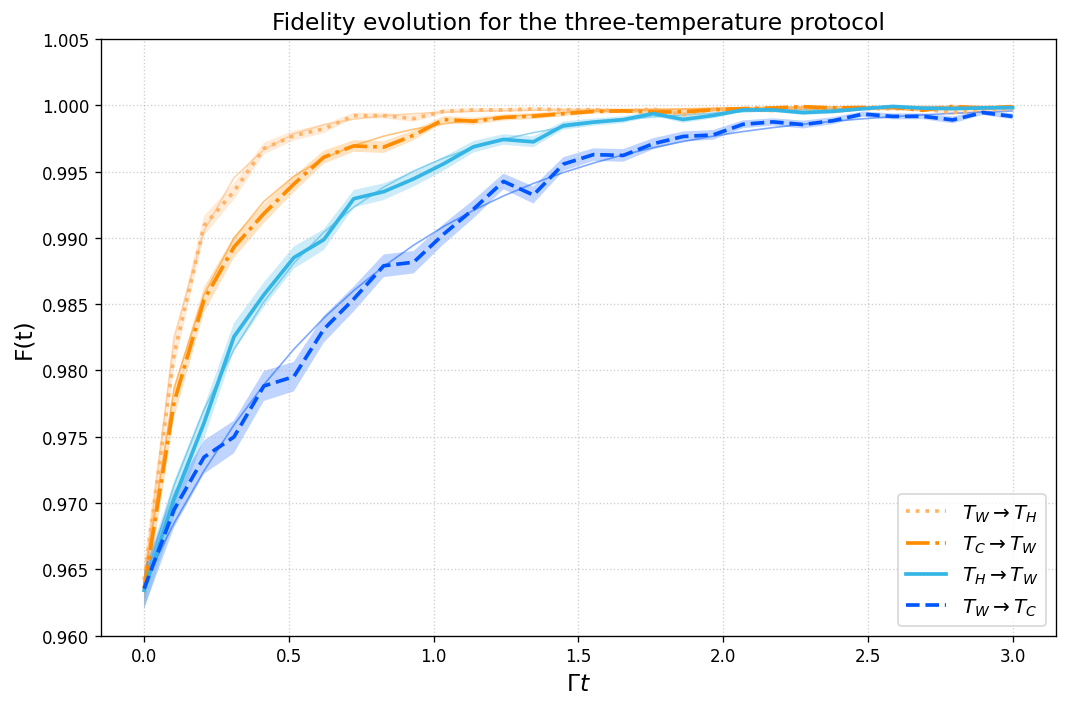

In [21]:
with open("exp_data_saved.pkl", "rb") as f:
    exp_data_saved = pickle.load(f)

# FIDELITY PLOT
plt.figure(figsize=(9, 6), dpi=120)

plot_styles = [
    {
        "color": "#FFB366",
        "linestyle": ":",
        "linewidth": 2.2,
    },  # dotted light: T_W -> T_H
    {
        "color": "#FF8C00",
        "linestyle": "-.",
        "linewidth": 2.2,
    },  # dashed-dotted orange: T_C -> T_W
    {
        "color": "#33B5E5",
        "linestyle": "-",
        "linewidth": 2.2,
    },  # solid light blue: T_H -> T_W
    {
        "color": "#0055FF",
        "linestyle": "--",
        "linewidth": 2.2,
    },  # dashed blue: T_W -> T_C
]

for i, d in enumerate(exp_data_saved):
    label = d["label"]
    fidelities = np.array(d["fidelities"])
    err_fidelities = np.array(d["err_fidelities"])
    fidelities_theo = np.array(d["fidelities_theo"])
    style = plot_styles[i]

    # theoretical fidelity 
    plt.plot(
        gamma_t_axis,
        fidelities_theo,
        color=style["color"],
        linestyle="-",
        linewidth=1.0,
        alpha=0.5,
        zorder=1,
    )

    # experimental / simulated fidelity
    plt.plot(
        gamma_t_axis,
        fidelities,
        label=label,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
    )

    # uncertainty (shadows)
    plt.fill_between(
        gamma_t_axis,
        fidelities - err_fidelities,
        fidelities + err_fidelities,
        color=style["color"],
        alpha=0.25,
        edgecolor="none",
    )

plt.xlabel(r"$\Gamma t$", fontsize=14)
plt.ylabel(r"F(t)", fontsize=14)
plt.title("Fidelity evolution for the three-temperature protocol", fontsize=14)
plt.ylim([0.96, 1.005])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12, loc="lower right")

plt.savefig("fidelity_evolution_3T.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

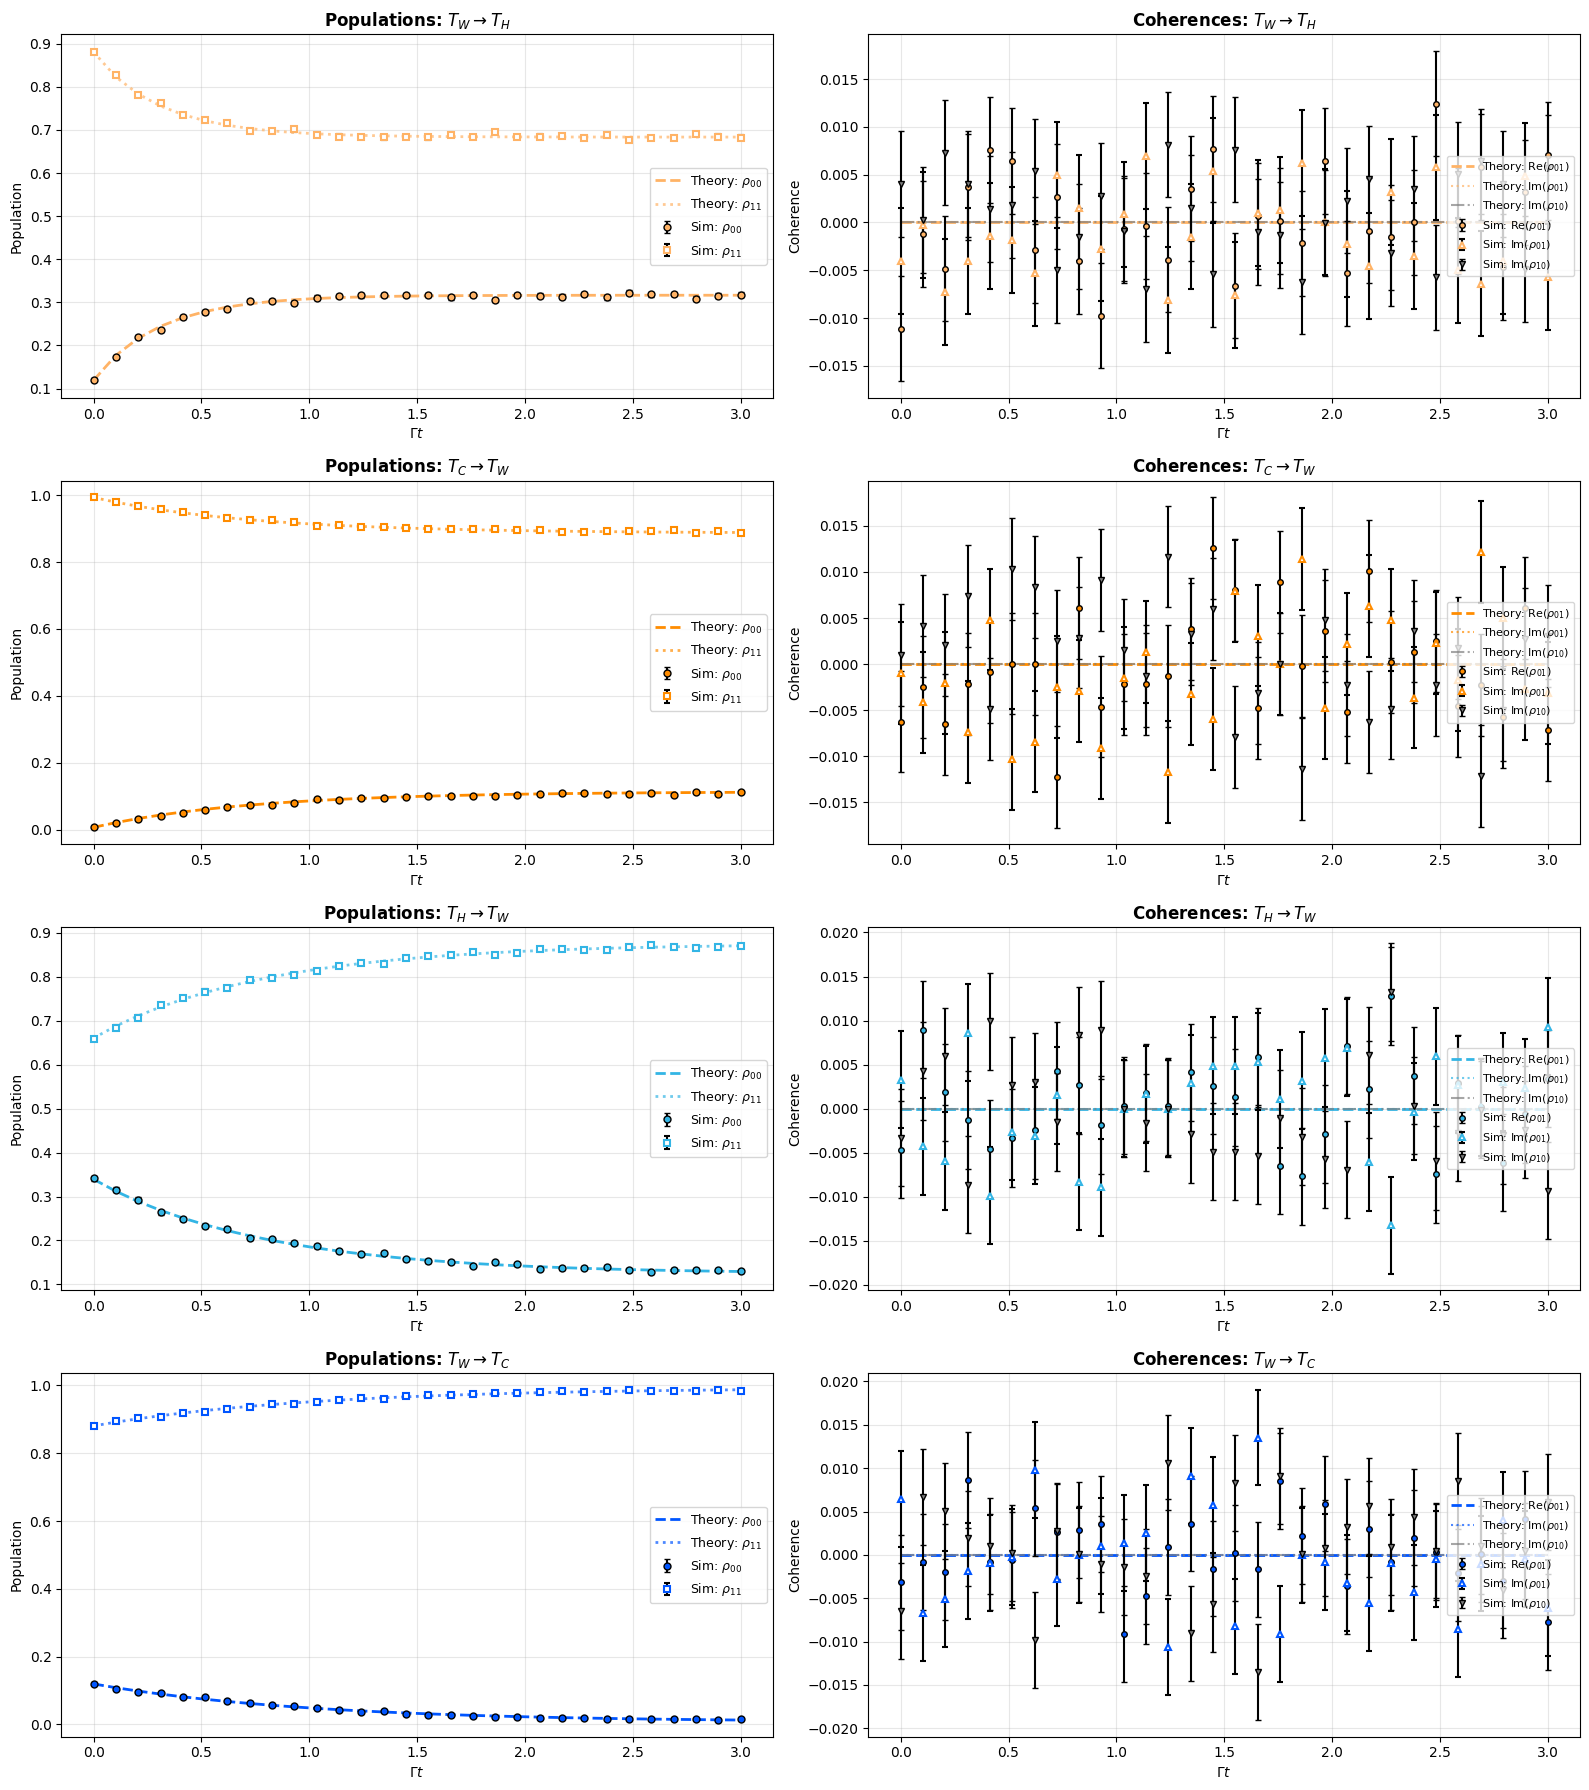

In [22]:
with open("exp_data_saved.pkl", "rb") as f:
    exp_data_saved = pickle.load(f)

gamma_t_axis = Gamma * times

# POPULATIONS & COHERENCES
fig, axes = plt.subplots(4, 2, figsize=(16, 18), dpi=100)

plot_styles = [
    {"color": "#FFB366", "linestyle": ":"},  # T_W -> T_H 
    {"color": "#FF8C00", "linestyle": "-."},  # T_C -> T_W
    {"color": "#33B5E5", "linestyle": "-"},  # T_H -> T_W 
    {"color": "#0055FF", "linestyle": "--"},  # T_W -> T_C 
]

for i, d in enumerate(exp_data_saved):
    label = d["label"]
    style = plot_styles[i]
    main_color = style["color"]

    # 1ST COLUMN: POPULATIONS
    ax_pop = axes[i, 0]

    # Theo
    ax_pop.plot(
        gamma_t_axis,
        d["theo"]["rho00"],
        label=r"Theory: $\rho_{00}$",
        color=main_color,
        lw=2,
        ls="--",
    )
    ax_pop.plot(
        gamma_t_axis,
        d["theo"]["rho11"],
        label=r"Theory: $\rho_{11}$",
        color=main_color,
        lw=2,
        ls=":",
        alpha=0.7,
    )


    # Exp
    ax_pop.errorbar(
        gamma_t_axis,
        d["exp"]["rho00"],
        yerr=d["errors"]["rho00"],
        fmt="o",
        color=main_color,
        ecolor="black",
        markeredgecolor="black",
        capsize=2,
        markersize=5,
        label=r"Sim: $\rho_{00}$",
    )
    ax_pop.errorbar(
        gamma_t_axis,
        d["exp"]["rho11"],
        yerr=d["errors"]["rho11"],
        fmt="s",
        color="white",
        ecolor="black",
        markeredgecolor=main_color,
        markeredgewidth=1.5,
        capsize=2,
        markersize=5,
        label=r"Sim: $\rho_{11}$",
    )

    ax_pop.set_title(f"Populations: {label}", fontsize=12, fontweight="bold")
    ax_pop.set_xlabel(r"$\Gamma t$", fontsize=10)
    ax_pop.set_ylabel("Population", fontsize=10)
    ax_pop.grid(True, alpha=0.3)
    ax_pop.legend(fontsize=9, loc="center right")

    # 2ND COLUMN: COHERENCES
    ax_coh = axes[i, 1]

    # Theo
    ax_coh.plot(
        gamma_t_axis,
        d["theo"]["rho01_re"],
        label=r"Theory: Re($\rho_{01}$)",
        color=main_color,
        lw=2,
        ls="--",
    )
    ax_coh.plot(
        gamma_t_axis,
        d["theo"]["rho01_im"],
        label=r"Theory: Im($\rho_{01}$)",
        color=main_color,
        lw=1.5,
        ls=":",
        alpha=0.7,
    )
    ax_coh.plot(
        gamma_t_axis,
        d["theo"]["rho10_im"],
        label=r"Theory: Im($\rho_{10}$)",
        color="gray",
        lw=1.5,
        ls="-.",
        alpha=0.7,
    )
    
    # Exp
    ax_coh.errorbar(
        gamma_t_axis,
        d["exp"]["rho01_re"],
        yerr=d["errors"]["rho01_re"],
        fmt="o",
        color=main_color,
        ecolor="black",
        markeredgecolor="black",
        capsize=2,
        markersize=4,
        label=r"Sim: Re($\rho_{01}$)",
    )
    ax_coh.errorbar(
        gamma_t_axis,
        d["exp"]["rho01_im"],
        yerr=d["errors"]["rho01_im"],
        fmt="^",
        color="white",
        ecolor="black",
        markeredgecolor=main_color,
        markeredgewidth=1.5,
        capsize=2,
        markersize=4,
        label=r"Sim: Im($\rho_{01}$)",
    )
    ax_coh.errorbar(
        gamma_t_axis,
        d["exp"]["rho10_im"],
        yerr=d["errors"]["rho10_im"],
        fmt="v",
        color="gray",
        ecolor="black",
        markeredgecolor="black",
        capsize=2,
        markersize=4,
        label=r"Sim: Im($\rho_{10}$)",
    )

    ax_coh.set_title(f"Coherences: {label}", fontsize=12, fontweight="bold")
    ax_coh.set_xlabel(r"$\Gamma t$", fontsize=10)
    ax_coh.set_ylabel("Coherence", fontsize=10)
    ax_coh.grid(True, alpha=0.3)
    ax_coh.legend(fontsize=8, loc="center right")

plt.savefig("pop_coh_evol_3T.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

-----------------------------------------

### 2 TEMPERATURES PROTOCOL

In [23]:
gamma_t_max_2T = 5.0
N_steps_2T = 30
dt_2T = gamma_t_max_2T / (Gamma * (N_steps_2T - 1))
times_2T = np.arange(0, N_steps_2T * dt_2T, dt_2T)
gamma_t_axis_2T = Gamma * times_2T

In [24]:
# Same T_C and T_H
experiments_config_2T = [
    (T_C, T_H, r"$T_C \rightarrow T_H$"),
    (T_H, T_C, r"$T_H \rightarrow T_C$"),
]

In [25]:
# THEORETICAL EVOLUTION
theo_results_2T = []

for T_system, T_bath, label in experiments_config_2T:
    rho_initial = get_thermal_state(T_system)
    rho_theo_list = []

    for n_idx in range(N_steps_2T):
        t_n = n_idx * dt_2T
        if n_idx == 0:
            rho_res = rho_initial.copy()
        else:
            U_n, _ = get_U_Ai_matrices(w, Gamma, T_bath, t_n)
            rho_total = np.zeros((2, 2), dtype=complex)

            for U_i in U_n:
                rho_ancilla = np.array([[1, 0], [0, 0]], dtype=complex)
                rho_in = DensityMatrix(np.kron(rho_ancilla, rho_initial))

                qc = QuantumCircuit(2)
                qc.unitary(Operator(U_i), [0, 1])

                rho_final = rho_in.evolve(qc).data
                rho_total += rho_final[:2, :2]

            rho_res = rho_total / np.trace(rho_total)

        rho_theo_list.append(rho_res)

    theo_results_2T.append(
        {
            "T_system": T_system,
            "T_bath": T_bath,
            "label": label,
            "rho_initial": rho_initial,
            "rho_theo_list": rho_theo_list,
        }
    )

print("Completed")    

Completed


In [26]:
# BUILD ALL CIRCUITS FOR THE 2 EXPERIMENTS 
all_circuits_2T = []
circuit_meta_2T = []
U_n_cache_2T = {}

for exp_idx, exp in enumerate(theo_results_2T):
    rho_initial = exp["rho_initial"]
    T_bath = exp["T_bath"]

    eigenvalues, eigenvectors = np.linalg.eigh(rho_initial)
    purified_state = np.zeros(4, dtype=complex)
    purified_state[0:2] = np.sqrt(eigenvalues[0]) * eigenvectors[:, 0]
    purified_state[2:4] = np.sqrt(eigenvalues[1]) * eigenvectors[:, 1]

    for n in range(N_steps_2T):
        t_n = n * dt_2T
        U_n, _ = get_U_Ai_matrices(w, Gamma, T_bath, t_n)
        U_n_cache_2T[(exp_idx, n)] = U_n

        for basis in ["Z", "X", "Y"]:
            for branch_idx, U_i in enumerate(U_n):
                qc = build_circuit(U_i, basis, purified_state)
                all_circuits_2T.append(qc)
                circuit_meta_2T.append(
                    {"exp_idx": exp_idx, "step": n, "basis": basis, "branch": branch_idx}
                )

print(f"Total circuits to send: {len(all_circuits_2T)}")

Total circuits to send: 702


In [27]:
# CONFIGURE BACKEND AND SEND THE JOB.
USE_IBM_HARDWARE_2T = False  # set to True to send this to a real IBM backend

if USE_IBM_HARDWARE_2T:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    service = QiskitRuntimeService(channel="ibm_quantum_platform")
    backend_2T = service.least_busy(operational=True, min_num_qubits=3)
    sampler_2T = Sampler(mode=backend_2T)
else:
    from qiskit_aer import AerSimulator
    from qiskit_aer.primitives import SamplerV2 as Sampler

    backend_2T = AerSimulator()
    sampler_2T = Sampler()

print("Backend:", backend_2T.name if hasattr(backend_2T, "name") else backend_2T)

pm_2T = generate_preset_pass_manager(backend=backend_2T, optimization_level=1)
isa_circuits_2T = [pm_2T.run(qc) for qc in all_circuits_2T]  # transpile

# we define a limit of circuits per job
MAX_CIRCUITS_PER_JOB_2T = 300 if USE_IBM_HARDWARE_2T else len(isa_circuits_2T)

job_records_2T = []
# loop with steps of size MAX_CIRCUITS_PER_JOB_2T
for start in range(0, len(isa_circuits_2T), MAX_CIRCUITS_PER_JOB_2T):
    # extract the subset of circuits corresponding to the current block
    chunk = isa_circuits_2T[start : start + MAX_CIRCUITS_PER_JOB_2T]
    # send the block of circuits
    job = sampler_2T.run(chunk, shots=shots)

    # dictionary to save trazability data of the block
    record = {
        "mode": "ibm" if USE_IBM_HARDWARE_2T else "local",
        "start": start,
        "end": start + len(chunk),
    }

    if USE_IBM_HARDWARE_2T:
        record["job_id"] = job.job_id()
        record["backend"] = backend_2T.name
        print(f"Submitted job {job.job_id()} for circuits [{start}:{start + len(chunk)})")
    else:
        result = job.result()
        # extract the counts dictionaries
        counts_chunk = [pub_result.data.meas.get_counts() for pub_result in result]
        # name of the file to save results
        chunk_file = f"local_counts_2T_{start}.pkl"
        with open(chunk_file, "wb") as f:
            pickle.dump(counts_chunk, f)
        record["counts_file"] = chunk_file
        print(f"Ran locally: circuits [{start}:{start + len(chunk)}) -> {chunk_file}")

    job_records_2T.append(record)

# save mode and indexes and counts
with open("ibm_jobs_2T.json", "w") as f:
    json.dump(job_records_2T, f, indent=2)

# save list of dictionaries to know what does position k represent, which of the 2 experiments is,
# the time step, the tomography basis, and the (branch) index of U_i,
# and a dictionary of the theoretical U_i calculated
with open("circuit_meta_2T.pkl", "wb") as f:
    pickle.dump({"circuit_meta": circuit_meta_2T, "U_n_cache": U_n_cache_2T}, f)

print("Everything is saved")


Backend: aer_simulator
Ran locally: circuits [0:702) -> local_counts_2T_0.pkl
Everything is saved


In [28]:
# RETRIEVE RESULTS AND BUILD exp_data_saved_2T
# open and read json to recover jobs
with open("ibm_jobs_2T.json") as f:
    job_records_2T = json.load(f)

# open and read pkl to recover data
with open("circuit_meta_2T.pkl", "rb") as f:
    cache_2T = pickle.load(f)
circuit_meta_2T = cache_2T["circuit_meta"]

# create an empty list with the size of the total number of circuits
all_counts_2T = [None] * len(circuit_meta_2T)

if any(rec["mode"] == "ibm" for rec in job_records_2T):  # if sent to IBM
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(channel="ibm_quantum_platform")

# iterate over the jobs already runned
for rec in job_records_2T:
    if rec["mode"] == "ibm":
        # if it comes from IBM download the results
        job = service.job(rec["job_id"])
        result = job.result()
        counts_chunk = [pub_result.data.meas.get_counts() for pub_result in result]
    else:
        with open(rec["counts_file"], "rb") as f:
            counts_chunk = pickle.load(f)
    for local_idx, counts in enumerate(counts_chunk):
        all_counts_2T[rec["start"] + local_idx] = counts

print("Retrieved results for", len(all_counts_2T), "circuits")

# save the tuple of counts (N00, N10) into the list grouped
grouped_2T = defaultdict(list)
for meta, counts in zip(circuit_meta_2T, all_counts_2T):
    key = (meta["exp_idx"], meta["step"], meta["basis"])
    N00 = counts.get("00", 0)
    N10 = counts.get("10", 0)
    grouped_2T[key].append((N00, N10))

exp_data_saved_2T = []
for exp_idx, exp in enumerate(theo_results_2T):
    label = exp["label"]
    T_bath = exp["T_bath"]

    # THEORETICAL
    rho_theo_list = exp["rho_theo_list"]

    rho00_theo = [np.real(r[0, 0]) for r in rho_theo_list]
    rho11_theo = [np.real(r[1, 1]) for r in rho_theo_list]
    rho01_re_theo = [np.real(r[0, 1]) for r in rho_theo_list]
    rho01_im_theo = [np.imag(r[0, 1]) for r in rho_theo_list]
    rho10_re_theo = [np.real(r[1, 0]) for r in rho_theo_list]
    rho10_im_theo = [np.imag(r[1, 0]) for r in rho_theo_list]

    # target thermal state and populations
    rho_target = get_thermal_state(T_bath)
    p0_tgt = np.real(rho_target[0, 0])
    p1_tgt = np.real(rho_target[1, 1])

    # THEORETICAL FIDELITY: exact Lindblad evolution vs target thermal state
    fidelities_theo = [fidelity(r, rho_target) for r in rho_theo_list]

    # Save experimental data
    rho00_exp, rho11_exp = [], []
    rho01_re_exp, rho01_im_exp = [], []
    rho10_re_exp, rho10_im_exp = [], []

    err_rho00, err_rho11 = [], []
    err_rho01_re, err_rho01_im = [], []
    err_rho10_re, err_rho10_im = [], []

    fidelities, err_fidelities = [], []

    # Time loop
    for n in range(N_steps_2T):

        # Tomography
        diag_Z = basis_expectation_from_counts(grouped_2T[(exp_idx, n, "Z")], shots)
        diag_X = basis_expectation_from_counts(grouped_2T[(exp_idx, n, "X")], shots)
        diag_Y = basis_expectation_from_counts(grouped_2T[(exp_idx, n, "Y")], shots)

        z_exp = diag_Z[0, 0] - diag_Z[1, 1]
        x_exp = diag_X[0, 0] - diag_X[1, 1]
        y_exp = diag_Y[0, 0] - diag_Y[1, 1]

        # Reconstruction of density matrix
        rho_n = np.array(
            [[0.5 * (1 + z_exp), 0.5 * (x_exp - 1j * y_exp)],
             [0.5 * (x_exp + 1j * y_exp), 0.5 * (1 - z_exp)]],
            dtype=complex,
        )

        r00 = np.real(rho_n[0, 0])
        r11 = np.real(rho_n[1, 1])
        r01_re = np.real(rho_n[0, 1])
        r01_im = np.imag(rho_n[0, 1])

        # Save matrix elements
        rho00_exp.append(r00)
        rho11_exp.append(r11)

        rho01_re_exp.append(r01_re)
        rho01_im_exp.append(r01_im)

        rho10_re_exp.append(r01_re)
        rho10_im_exp.append(-r01_im)

        # Uncertainties of matrix elements
        u_r00 = 0.5 * np.sqrt(max(0.0, 1.0 - z_exp**2) / shots)
        u_r01_re = 0.5 * np.sqrt(max(0.0, 1.0 - x_exp**2) / shots)
        u_r01_im = 0.5 * np.sqrt(max(0.0, 1.0 - y_exp**2) / shots)

        err_rho00.append(u_r00)
        err_rho11.append(u_r00)

        err_rho01_re.append(u_r01_re)
        err_rho01_im.append(u_r01_im)

        err_rho10_re.append(u_r01_re)
        err_rho10_im.append(u_r01_im)

        # FIDELITY
        F_val = fidelity(rho_n, rho_target)
        fidelities.append(F_val)

        # uncertainty of fidelity
        abs_rho01_sq = r01_re**2 + r01_im**2
        det_rho = max(1e-12, r00 * r11 - abs_rho01_sq)
        sqrt_det = np.sqrt(det_rho)

        # sqrt(G) = F
        # derivatives dG/d(rho_ij)
        dG_drho00 = p0_tgt - p1_tgt + (np.sqrt(p0_tgt * p1_tgt) * (r11 - r00)) / sqrt_det
        dG_dre01 = (-2.0 * np.sqrt(p0_tgt * p1_tgt) * r01_re) / sqrt_det
        dG_dim01 = (-2.0 * np.sqrt(p0_tgt * p1_tgt) * r01_im) / sqrt_det

        # derivatives dF/d(rho_ij) = dG/d(rho_ij) / (2 * F)
        denom_2F = 2.0 * max(1e-6, F_val)
        dF_drho00 = dG_drho00 / denom_2F
        dF_dre01 = dG_dre01 / denom_2F
        dF_dim01 = dG_dim01 / denom_2F

        u_F = np.sqrt(
            (dF_drho00**2) * (u_r00**2)
            + (dF_dre01**2) * (u_r01_re**2)
            + (dF_dim01**2) * (u_r01_im**2)
        )
        err_fidelities.append(u_F)

    exp_data_saved_2T.append(
        {
            "label": exp["label"],
            "T_system": exp["T_system"],
            "T_bath": exp["T_bath"],
            "gamma_t_axis": gamma_t_axis_2T,
            "fidelities": fidelities,
            "err_fidelities": err_fidelities,
            "fidelities_theo": fidelities_theo,
            "theo": {
                "rho00": rho00_theo,
                "rho11": rho11_theo,
                "rho01_re": rho01_re_theo,
                "rho01_im": rho01_im_theo,
                "rho10_re": rho10_re_theo,
                "rho10_im": rho10_im_theo,
            },
            "exp": {
                "rho00": rho00_exp,
                "rho11": rho11_exp,
                "rho01_re": rho01_re_exp,
                "rho01_im": rho01_im_exp,
                "rho10_re": rho10_re_exp,
                "rho10_im": rho10_im_exp,
            },
            "errors": {
                "rho00": err_rho00,
                "rho11": err_rho11,
                "rho01_re": err_rho01_re,
                "rho01_im": err_rho01_im,
                "rho10_re": err_rho10_re,
                "rho10_im": err_rho10_im,
            },
        }
    )

with open("exp_data_saved_2T.pkl", "wb") as f:
    pickle.dump(exp_data_saved_2T, f)

print("All the data are saved")


Retrieved results for 702 circuits
All the data are saved


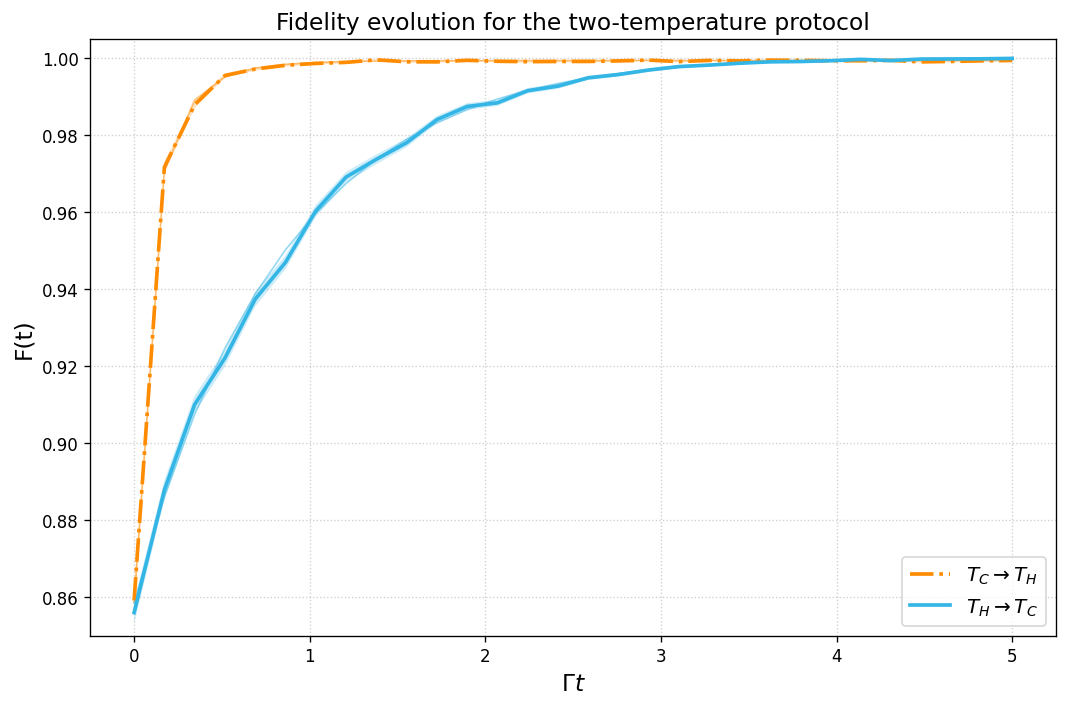

In [29]:
with open("exp_data_saved_2T.pkl", "rb") as f:
    exp_data_saved_2T = pickle.load(f)

# FIDELITY PLOT
plt.figure(figsize=(9, 6), dpi=120)

plot_styles_2T = [
    {
        "color": "#FF8C00",
        "linestyle": "-.",
        "linewidth": 2.2,
    },  # dashed-dotted orange: T_C -> T_H
    {
        "color": "#33B5E5",
        "linestyle": "-",
        "linewidth": 2.2,
    },  # solid light blue: T_H -> T_C
]

for i, d in enumerate(exp_data_saved_2T):
    label = d["label"]
    fidelities = np.array(d["fidelities"])
    err_fidelities = np.array(d["err_fidelities"])
    fidelities_theo = np.array(d["fidelities_theo"])
    style = plot_styles_2T[i]

    # theoretical fidelity
    plt.plot(
        gamma_t_axis_2T,
        fidelities_theo,
        color=style["color"],
        linestyle="-",
        linewidth=1.0,
        alpha=0.5,
        zorder=1,
    )

    # experimental / simulated fidelity
    plt.plot(
        gamma_t_axis_2T,
        fidelities,
        label=label,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
    )

    # uncertainty (shadows)
    plt.fill_between(
        gamma_t_axis_2T,
        fidelities - err_fidelities,
        fidelities + err_fidelities,
        color=style["color"],
        alpha=0.25,
        edgecolor="none",
    )

plt.xlabel(r"$\Gamma t$", fontsize=14)
plt.ylabel(r"F(t)", fontsize=14)
plt.title("Fidelity evolution for the two-temperature protocol", fontsize=14)
plt.ylim([0.85, 1.005])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12, loc="lower right")

plt.savefig("fidelity_evolution_2T.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


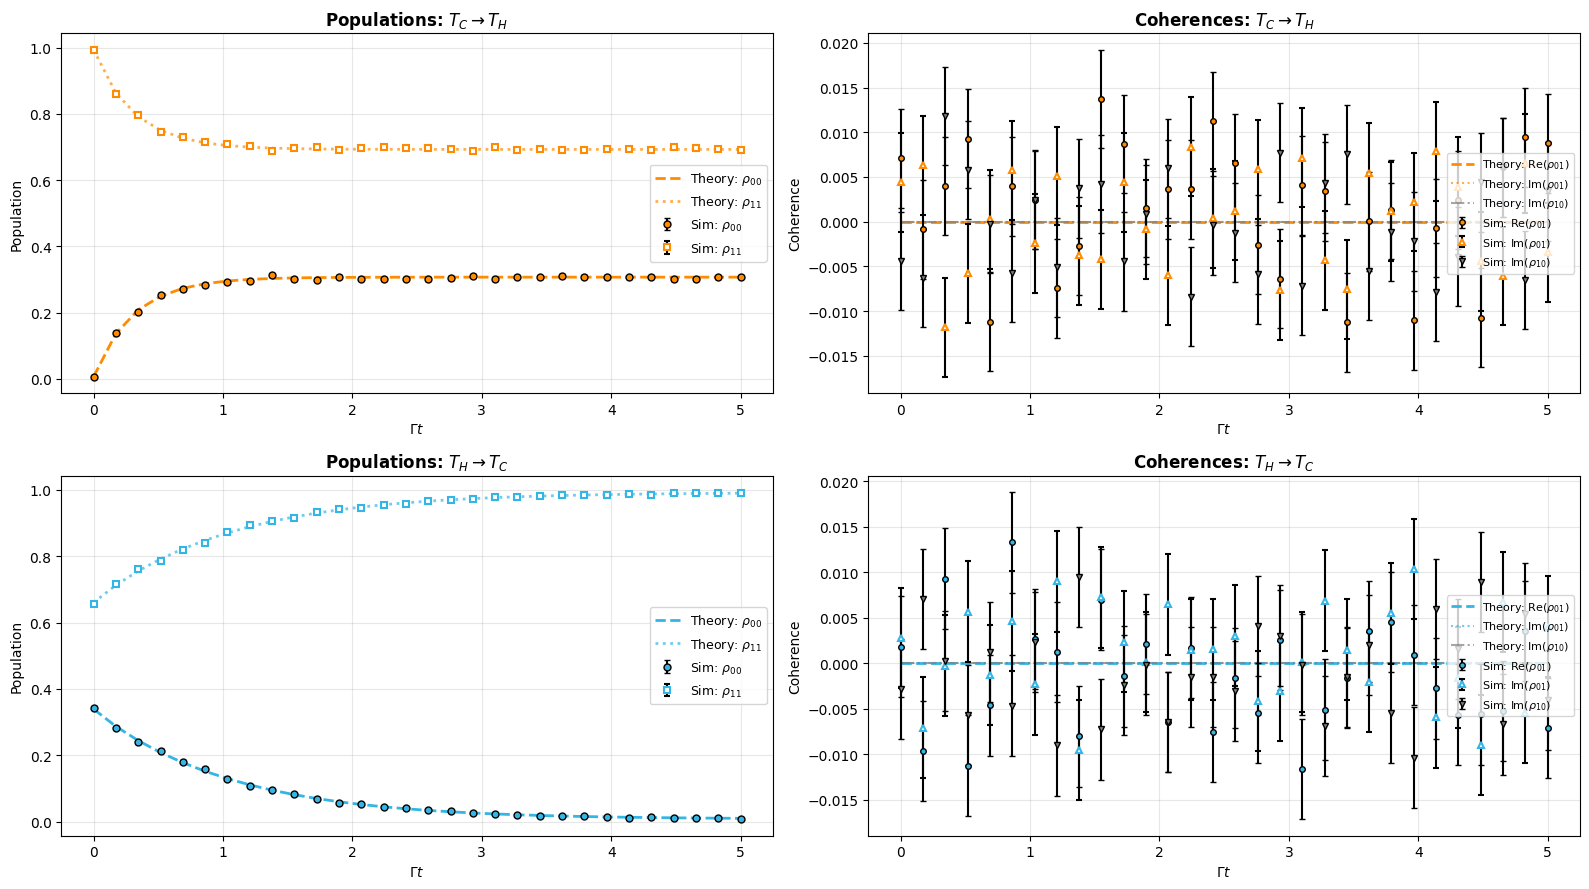

In [30]:
with open("exp_data_saved_2T.pkl", "rb") as f:
    exp_data_saved_2T = pickle.load(f)

gamma_t_axis_2T = Gamma * times_2T

# POPULATIONS & COHERENCES
fig, axes = plt.subplots(2, 2, figsize=(16, 9), dpi=100)

plot_styles_2T = [
    {"color": "#FF8C00", "linestyle": "-."},  # T_C -> T_H
    {"color": "#33B5E5", "linestyle": "-"},   # T_H -> T_C
]

for i, d in enumerate(exp_data_saved_2T):
    label = d["label"]
    style = plot_styles_2T[i]
    main_color = style["color"]

    # 1ST COLUMN: POPULATIONS
    ax_pop = axes[i, 0]

    # Theo
    ax_pop.plot(
        gamma_t_axis_2T,
        d["theo"]["rho00"],
        label=r"Theory: $\rho_{00}$",
        color=main_color,
        lw=2,
        ls="--",
    )
    ax_pop.plot(
        gamma_t_axis_2T,
        d["theo"]["rho11"],
        label=r"Theory: $\rho_{11}$",
        color=main_color,
        lw=2,
        ls=":",
        alpha=0.7,
    )

    # Exp
    ax_pop.errorbar(
        gamma_t_axis_2T,
        d["exp"]["rho00"],
        yerr=d["errors"]["rho00"],
        fmt="o",
        color=main_color,
        ecolor="black",
        markeredgecolor="black",
        capsize=2,
        markersize=5,
        label=r"Sim: $\rho_{00}$",
    )
    ax_pop.errorbar(
        gamma_t_axis_2T,
        d["exp"]["rho11"],
        yerr=d["errors"]["rho11"],
        fmt="s",
        color="white",
        ecolor="black",
        markeredgecolor=main_color,
        markeredgewidth=1.5,
        capsize=2,
        markersize=5,
        label=r"Sim: $\rho_{11}$",
    )

    ax_pop.set_title(f"Populations: {label}", fontsize=12, fontweight="bold")
    ax_pop.set_xlabel(r"$\Gamma t$", fontsize=10)
    ax_pop.set_ylabel("Population", fontsize=10)
    ax_pop.grid(True, alpha=0.3)
    ax_pop.legend(fontsize=9, loc="center right")

    # 2ND COLUMN: COHERENCES
    ax_coh = axes[i, 1]

    # Theo
    ax_coh.plot(
        gamma_t_axis_2T,
        d["theo"]["rho01_re"],
        label=r"Theory: Re($\rho_{01}$)",
        color=main_color,
        lw=2,
        ls="--",
    )
    ax_coh.plot(
        gamma_t_axis_2T,
        d["theo"]["rho01_im"],
        label=r"Theory: Im($\rho_{01}$)",
        color=main_color,
        lw=1.5,
        ls=":",
        alpha=0.7,
    )

    ax_coh.plot(
        gamma_t_axis_2T,
        d["theo"]["rho10_im"],
        label=r"Theory: Im($\rho_{10}$)",
        color="gray",
        lw=1.5,
        ls="-.",
        alpha=0.7,
    )

    # Exp
    ax_coh.errorbar(
        gamma_t_axis_2T,
        d["exp"]["rho01_re"],
        yerr=d["errors"]["rho01_re"],
        fmt="o",
        color=main_color,
        ecolor="black",
        markeredgecolor="black",
        capsize=2,
        markersize=4,
        label=r"Sim: Re($\rho_{01}$)",
    )
    ax_coh.errorbar(
        gamma_t_axis_2T,
        d["exp"]["rho01_im"],
        yerr=d["errors"]["rho01_im"],
        fmt="^",
        color="white",
        ecolor="black",
        markeredgecolor=main_color,
        markeredgewidth=1.5,
        capsize=2,
        markersize=4,
        label=r"Sim: Im($\rho_{01}$)",
    )
    ax_coh.errorbar(
        gamma_t_axis_2T,
        d["exp"]["rho10_im"],
        yerr=d["errors"]["rho10_im"],
        fmt="v",
        color="gray",
        ecolor="black",
        markeredgecolor="black",
        capsize=2,
        markersize=4,
        label=r"Sim: Im($\rho_{10}$)",
    )

    ax_coh.set_title(f"Coherences: {label}", fontsize=12, fontweight="bold")
    ax_coh.set_xlabel(r"$\Gamma t$", fontsize=10)
    ax_coh.set_ylabel("Coherence", fontsize=10)
    ax_coh.grid(True, alpha=0.3)
    ax_coh.legend(fontsize=8, loc="center right")

plt.savefig("pop_coh_evol_2T.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


--------------------

### SCHEMES

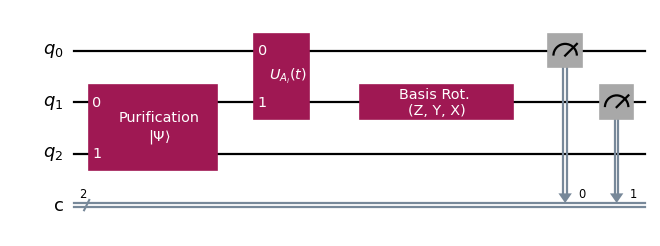

In [31]:
import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

qr = QuantumRegister(3, name="q")
cr = ClassicalRegister(2, name="c")
qc = QuantumCircuit(qr, cr)

# subcircuit: purification (q1, q2)
sub_purif = QuantumCircuit(2, name=r"Purification" + "\n" + r"$|\Psi\rangle$")
gate_purif = sub_purif.to_gate()

# subcircuit: U_Ai (q0, q1)
sub_u_ai = QuantumCircuit(2, name=r"$U_{A_i}(t)$")
gate_u_ai = sub_u_ai.to_gate()

# subcircuit: Basis Rotation (q1)
sub_basis = QuantumCircuit(1, name="Basis Rot. \n(Z, Y, X)")
gate_basis = sub_basis.to_gate()


qc.append(gate_purif, [1, 2])
#qc.barrier()

qc.append(gate_u_ai, [0, 1])
#qc.barrier()

qc.append(gate_basis, [1])
#qc.barrier()

qc.measure(0, 0) 
qc.measure(1, 1) 

fig = qc.draw(output="mpl", style="iqp", scale=0.8)

fig.savefig("part_circuit.png", dpi=300, bbox_inches="tight")

plt.show(block=True)
display(fig)

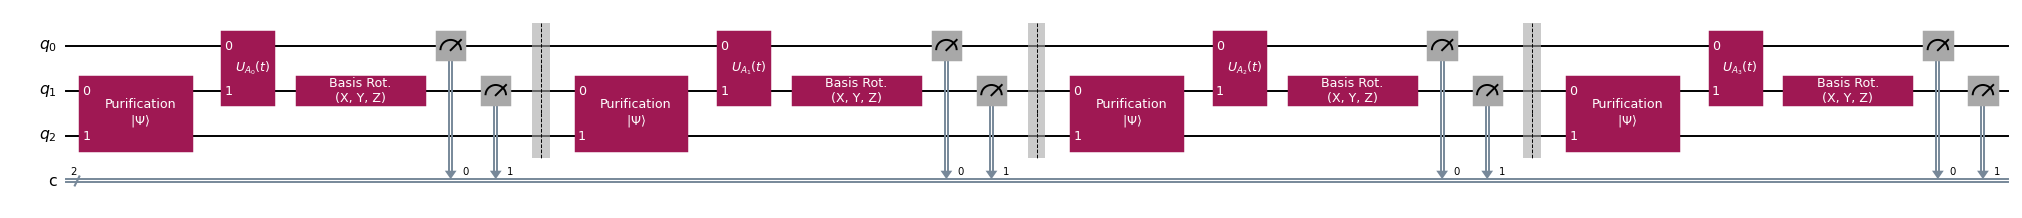

In [32]:
import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

qr = QuantumRegister(3, name="q")
cr = ClassicalRegister(2, name="c")
qc = QuantumCircuit(qr, cr)

sub_purif = QuantumCircuit(2, name=r"Purification" + "\n" + r"$|\Psi\rangle$")
gate_purif = sub_purif.to_gate()

sub_basis = QuantumCircuit(1, name="Basis Rot.\n(X, Y, Z)")
gate_basis = sub_basis.to_gate()

for i in range(4):
    qc.append(gate_purif, [1, 2])

    sub_u_ai = QuantumCircuit(2, name=f"$U_{{A_{i}}}(t)$")
    gate_u_ai = sub_u_ai.to_gate()

    qc.append(gate_u_ai, [0, 1])
    qc.append(gate_basis, [1])
    qc.measure(0, 0)
    qc.measure(1, 1)

    if i < 3:
        qc.barrier()

fig = qc.draw(output="mpl", style="iqp", scale=0.7, fold=-1)
fig.savefig("whole_circuit_clean.png", dpi=300, bbox_inches="tight")

plt.show(block=True)
display(fig)